In [1]:
import pandas as pd
file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"
excel_file = pd.ExcelFile(file_path)
print("Available Sheets:")
print(excel_file.sheet_names)
df = pd.read_excel(file_path, sheet_name="marketing_campaign")
print("\nFirst 5 Records:")
print(df.head())
print("\nDataset Information:")
print(df.info())
print("\nShape of Dataset:")
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
feature_types = {
    "ID": "Nominal",
    "Year_Birth": "Interval",
    "Education": "Ordinal",
    "Marital_Status": "Nominal",
    "Income": "Ratio",
    "Kidhome": "Ratio",
    "Teenhome": "Ratio",
    "Dt_Customer": "Interval",
    "Recency": "Ratio",
    "MntWines": "Ratio",
    "MntFruits": "Ratio",
    "MntMeatProducts": "Ratio",
    "MntFishProducts": "Ratio",
    "MntSweetProducts": "Ratio",
    "MntGoldProds": "Ratio",
    "NumDealsPurchases": "Ratio",
    "NumWebPurchases": "Ratio",
    "NumCatalogPurchases": "Ratio",
    "NumStorePurchases": "Ratio",
    "NumWebVisitsMonth": "Ratio",
    "AcceptedCmp1": "Nominal",
    "AcceptedCmp2": "Nominal",
    "AcceptedCmp3": "Nominal",
    "AcceptedCmp4": "Nominal",
    "AcceptedCmp5": "Nominal",
    "Complain": "Nominal",
    "Response": "Nominal"
}
print("\nFeature Types:")
print("-" * 40)
for column in df.columns:
    if column in feature_types:
        print(f"{column:<25} : {feature_types[column]}")
    else:
        print(f"{column:<25} : Not Classified")

Available Sheets:
['Purchase data', 'IRCTC Stock Price', 'thyroid0387_UCI', 'marketing_campaign']

First 5 Records:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6   
4           19-01-2014       94       173  ...                  5   



In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"
df = pd.read_excel(file_path, sheet_name="marketing_campaign")
def label_encoding(data, column_name):
    le = LabelEncoder()
    encoded_data = data.copy()
    encoded_data[column_name] = le.fit_transform(encoded_data[column_name].astype(str))
    print(f"\nLabel Encoding for '{column_name}'")
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Mapping:")
    print(mapping)
    return encoded_data
def one_hot_encoding(data, column_name):
    encoded_data = pd.get_dummies(data, columns=[column_name])

    print(f"\nOne-Hot Encoding completed for '{column_name}'")
    return encoded_data
label_encoded_df = label_encoding(df, "Education")
print("\nFirst 5 rows after Label Encoding:")
print(label_encoded_df.head())

onehot_encoded_df = one_hot_encoding(df, "Education")
print("\nFirst 5 rows after One-Hot Encoding:")
print(onehot_encoded_df.head())


Label Encoding for 'Education'
Mapping:
{'2n Cycle': np.int64(0), 'Basic': np.int64(1), 'Graduation': np.int64(2), 'Master': np.int64(3), 'PhD': np.int64(4)}

First 5 rows after Label Encoding:
     ID  Year_Birth  Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957          2         Single  58138.0        0         0   
1  2174        1954          2         Single  46344.0        1         1   
2  4141        1965          2       Together  71613.0        0         0   
3  6182        1984          2       Together  26646.0        1         0   
4  5324        1981          4        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6 

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"
df = pd.read_excel(file_path, sheet_name="marketing_campaign")
print("Original Dataset Shape:", df.shape)
categorical_columns = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(categorical_columns)
label_df = df.copy()

le = LabelEncoder()

for column in categorical_columns:
    label_df[column] = le.fit_transform(label_df[column].astype(str))

print("\nShape after Label Encoding:")
print(label_df.shape)
onehot_df = pd.get_dummies(df, columns=categorical_columns)

print("\nShape after One-Hot Encoding:")
print(onehot_df.shape)
print("\nFeature Comparison")
print("-------------------------")
print("Original Features      :", df.shape[1])
print("After Label Encoding   :", label_df.shape[1])
print("After One-Hot Encoding :", onehot_df.shape[1])

Original Dataset Shape: (2240, 29)

Categorical Columns:
Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

Shape after Label Encoding:
(2240, 29)

Shape after One-Hot Encoding:
(2240, 702)

Feature Comparison
-------------------------
Original Features      : 29
After Label Encoding   : 29
After One-Hot Encoding : 702


In [2]:

# A4 - Generalized Minkowski Distance


import math
def minkowski_distance(vector1, vector2, p):
    if len(vector1) != len(vector2):
        print("Vectors must have the same length.")
        return None
    distance = 0
    for i in range(len(vector1)):
        distance += abs(vector1[i] - vector2[i]) ** p
    distance = distance ** (1 / p)
    return distance
A = [2, 4, 6, 8]
B = [1, 3, 5, 7]
print("Manhattan Distance (p=1):")
print(minkowski_distance(A, B, 1))
print("\nEuclidean Distance (p=2):")
print(minkowski_distance(A, B, 2))
print("\nMinkowski Distance (p=3):")
print(minkowski_distance(A, B, 3))

Manhattan Distance (p=1):
4.0

Euclidean Distance (p=2):
2.0

Minkowski Distance (p=3):
1.5874010519681994


In [3]:

# A5 - Minkowski Distance for p = 1 to 10

def minkowski_distance(vector1, vector2, p):

    if len(vector1) != len(vector2):
        print("Vectors must have the same length.")
        return None

    distance = 0

    for i in range(len(vector1)):
        distance += abs(vector1[i] - vector2[i]) ** p

    return distance ** (1 / p)

A = [2, 4, 6, 8]
B = [1, 3, 5, 7]

print("p\tMinkowski Distance")
print("---------------------------")

for p in range(1, 11):
    distance = minkowski_distance(A, B, p)
    print(f"{p}\t{distance:.4f}")

p	Minkowski Distance
---------------------------
1	4.0000
2	2.0000
3	1.5874
4	1.4142
5	1.3195
6	1.2599
7	1.2190
8	1.1892
9	1.1665
10	1.1487


In [4]:
# A6 - Compare with SciPy Minkowski Distance

from scipy.spatial.distance import minkowski
def my_minkowski(vector1, vector2, p):

    if len(vector1) != len(vector2):
        print("Vectors must have the same length.")
        return None

    distance = 0

    for i in range(len(vector1)):
        distance += abs(vector1[i] - vector2[i]) ** p

    return distance ** (1 / p)

A = [2, 4, 6, 8]
B = [1, 3, 5, 7]

print("p\tMy Function\tSciPy Function")
print("-----------------------------------------")

for p in range(1, 11):

    my_distance = my_minkowski(A, B, p)
    scipy_distance = minkowski(A, B, p)

    print(f"{p}\t{my_distance:.4f}\t\t{scipy_distance:.4f}")

p	My Function	SciPy Function
-----------------------------------------
1	4.0000		4.0000
2	2.0000		2.0000
3	1.5874		1.5874
4	1.4142		1.4142
5	1.3195		1.3195
6	1.2599		1.2599
7	1.2190		1.2190
8	1.1892		1.1892
9	1.1665		1.1665
10	1.1487		1.1487


In [5]:

# A7 - Dot Product and Euclidean Norm

import numpy as np

A = np.array([2, 4, 6, 8])
B = np.array([1, 3, 5, 7])

dot_product = np.dot(A, B)

norm_A = np.linalg.norm(A)
norm_B = np.linalg.norm(B)

print("Vector A:", A)
print("Vector B:", B)

print("\nDot Product:", dot_product)
print("Euclidean Norm of A:", norm_A)
print("Euclidean Norm of B:", norm_B)

Vector A: [2 4 6 8]
Vector B: [1 3 5 7]

Dot Product: 100
Euclidean Norm of A: 10.954451150103322
Euclidean Norm of B: 9.16515138991168


In [6]:
# A8 - Mean, Variance and Standard Deviation

import pandas as pd
import math

file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"

df = pd.read_excel(file_path, sheet_name="marketing_campaign")

data = df["Income"].dropna().tolist()

mean = sum(data) / len(data)

variance = 0

for value in data:
    variance += (value - mean) ** 2

variance = variance / len(data)

std_dev = math.sqrt(variance)

print("Feature: Income")
print("Mean =", mean)
print("Variance =", variance)
print("Standard Deviation =", std_dev)

Feature: Income
Mean = 52247.25135379061
Variance = 633397830.1872728
Standard Deviation = 25167.39617416297


In [7]:
# A9 - Verify Using NumPy


import pandas as pd
import numpy as np
file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"

df = pd.read_excel(file_path, sheet_name="marketing_campaign")
data = df["Income"].dropna()

mean = np.mean(data)
variance = np.var(data)
std_dev = np.std(data)

print("Feature: Income")
print("Mean =", mean)
print("Variance =", variance)
print("Standard Deviation =", std_dev)

Feature: Income
Mean = 52247.25135379061
Variance = 633397830.1872725
Standard Deviation = 25167.396174162965


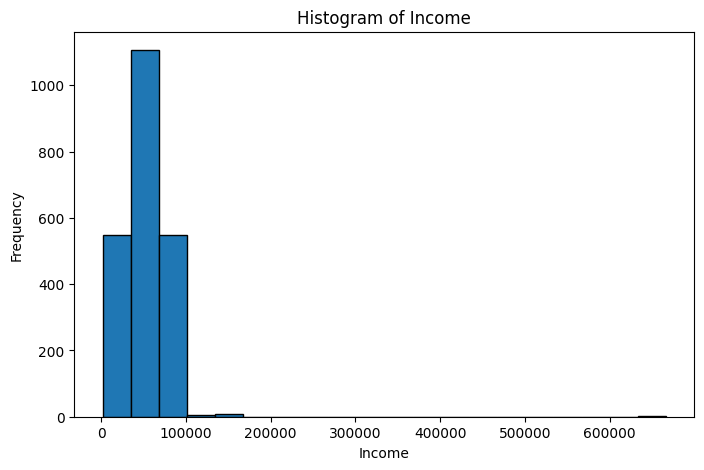

In [1]:

# A10 - Histogram Analysis
import pandas as pd
import matplotlib.pyplot as plt
file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"
df = pd.read_excel(file_path, sheet_name="marketing_campaign")
data = df["Income"].dropna()
plt.figure(figsize=(8,5))
plt.hist(data, bins=20, edgecolor='black')
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

/Users/velagapudiruthvika/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/velagapudiruthvika/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/velagapudiruthvika/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/velagapudiruthvika/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/velagapudiruthvika/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/velagapudiruthvika/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: Runt

First Five Rows:
    Income  MntWines  Cluster
0  58138.0       635        2
1  46344.0        11        0
2  71613.0       426        2
3  26646.0        11        0
4  58293.0       173        0


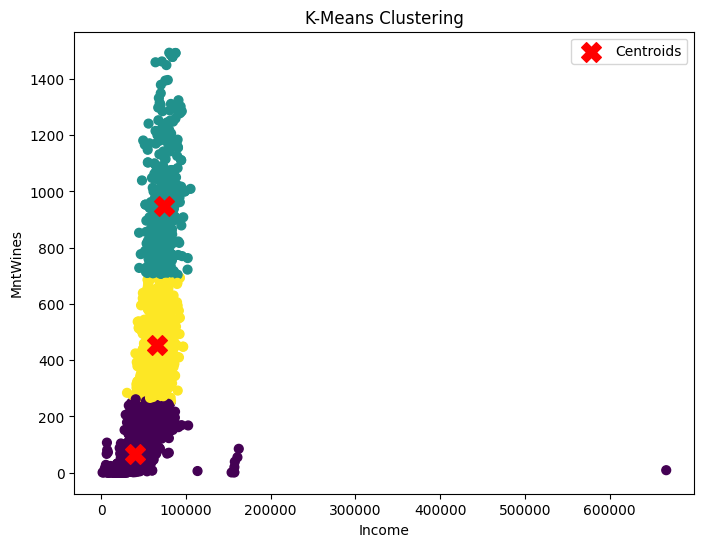

In [8]:
# A11 - K-Means Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

file_path = "/Users/velagapudiruthvika/Downloads/Lab Session Data (1).xlsx"

df = pd.read_excel(file_path, sheet_name="marketing_campaign")

X = df[['Income', 'MntWines']].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna().reset_index(drop=True)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

X['Cluster'] = kmeans.fit_predict(X_scaled)

print("First Five Rows:")
print(X.head())

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    X['Income'],
    X['MntWines'],
    c=X['Cluster'],
    cmap='viridis',
    s=40
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clustering")
plt.xlabel("Income")
plt.ylabel("MntWines")
plt.legend()

plt.show()